In [4]:
!nvidia-smi

Mon Apr 27 15:29:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [23]:
%%writefile matrix_mult_gpu.cu

#include <stdio.h>

int SIZE = 20;

__global__ void matrix_multiplication_kernel(float *a, float *b, float *c, int N) {
  int row = blockIdx.y  * blockDim.y + threadIdx.y;
  int col = blockIdx.x  * blockDim.x + threadIdx.x;

  if (row < N && col < N) {
      float sum = 0.0;

      for (int i = 0; i < N; i++)
        sum += a[row * N + i] * b[i * N + col];
      c[row * N + col] = sum;
  }
}

void allocating_data(float *h_a, float *h_b, float *h_c, int N) {
  float *d_a = nullptr, *d_b = nullptr, *d_c = nullptr;

  cudaMalloc(&d_a, N * N * sizeof(float));
  cudaMalloc(&d_b, N * N * sizeof(float));
  cudaMalloc(&d_c, N * N * sizeof(float));

  cudaMemcpy(d_a, h_a, N * N * sizeof(float), cudaMemcpyHostToDevice);
  cudaMemcpy(d_b, h_b, N * N * sizeof(float), cudaMemcpyHostToDevice);
  cudaMemcpy(d_c, h_c, N * N * sizeof(float), cudaMemcpyHostToDevice);

  int blockSize = 16;
  dim3 threadsPerBlock(blockSize, blockSize);
  dim3 blocksPerGrid((N + blockSize - 1) / blockSize,(N + blockSize - 1) / blockSize);

  cudaEvent_t start, stop;
  cudaEventCreate(&start);
  cudaEventCreate(&stop);

  cudaEventRecord(start);
  matrix_multiplication_kernel<<<blocksPerGrid, threadsPerBlock>>>(d_a, d_b, d_c, N);
  cudaEventRecord(stop);

  cudaEventSynchronize(stop);
  cudaMemcpy(h_c, d_c, N * N * sizeof(float), cudaMemcpyDeviceToHost);

  cudaFree(d_a);
  cudaFree(d_b);
  cudaFree(d_c);

  float milliseconds = 0;
  cudaEventElapsedTime(&milliseconds, start, stop);
  printf("%f", milliseconds);

/*
  for (int i = 0; i < N; i++) {
    for (int j = 0; j < N; j++) {
      printf("%.2f ", h_c[i * N + j]);
    }
    printf("\n");
  }
*/

}

int main(int argc, char **argv) {

  if (argc != 2) {
    printf("Usage: %s <matrix_size>\n", argv[0]);
    return -1;
  }

  int N = atoi(argv[1]);

  float *mat_a, *mat_b, *mat_c;

  // Allocating memory for the matrices
  mat_a = (float *)malloc(N * N * sizeof(float));
  mat_b = (float *)malloc(N * N * sizeof(float));
  mat_c = (float *)malloc(N * N * sizeof(float));

  // Initializing the matrices
  for (int i = 0; i < N; i++) {
    for (int j = 0; j < N; j++) {
      mat_a[i * N + j] = 1.0;
      mat_b[i * N + j] = 1.0;

      // Need to initialize matrix c to 0, if we don't, garbage values get added to result
      mat_c[i * N + j] = 0.0;
    }
  }

  allocating_data(&mat_a[0], &mat_b[0], &mat_c[0], N);

  free(mat_a);
  free(mat_b);
  free(mat_c);

  return 0;
}


Overwriting matrix_mult_gpu.cu


In [24]:
!nvcc -arch=sm_75 matrix_mult_gpu.cu -o matrix_mult_gpu

In [25]:
!./matrix_mult_gpu 1024

7.093568

In [14]:
%%writefile matrix_mult_cpu.cu

#include <stdio.h>
#include <chrono>

int main(int argc, char **argv) {

  if (argc != 2) {
    printf("Usage: %s <matrix_size>\n", argv[0]);
    return -1;
  }

  int N = atoi(argv[1]);
  float *mat_a, *mat_b, *mat_c;

  // Allocating memory for the matrices
  mat_a = (float *)malloc(N * N * sizeof(float));
  mat_b = (float *)malloc(N * N * sizeof(float));
  mat_c = (float *)malloc(N * N * sizeof(float));

  // Initializing the matrices
  for (int i = 0; i < N; i++) {
    for (int j = 0; j < N; j++) {
      mat_a[i * N + j] = 1.0;
      mat_b[i * N + j] = 1.0;

      // Need to initialize matrix c to 0, if we don't, garbage values get added to result
      mat_c[i * N + j] = 0.0;
    }
  }

  auto start = std::chrono::high_resolution_clock::now();
  // Multiplying the matrices and storing the output in mat_c
  for (int i = 0; i < N; i++) {
    for (int j = 0; j < N; j++) {
      for (int k = 0; k < N; k++) {
        mat_c[i * N + j] += mat_a[i * N + k] * mat_b[k * N + j];
      }
    }
  }

  auto end = std::chrono::high_resolution_clock::now();

  std::chrono::duration<float, std::milli> duration = end - start;
  printf("%.2f", duration.count());

 /*
  for (int i = 0; i < N; i++) {
    for (int j = 0; j < N; j++) {
      printf("%.2f ", mat_c[i * j + N]);
    }
    printf("\n");
  }
 */

  free(mat_a);
  free(mat_b);
  free(mat_c);

  return 0;
}

Overwriting matrix_mult_cpu.cu


In [26]:
!nvcc -arch=sm_75 matrix_mult_cpu.cu -o matrix_mult_cpu

In [27]:
!./matrix_mult_cpu 128

0.01

Benchmarking N=128...
Benchmarking N=256...
Benchmarking N=512...
Benchmarking N=1024...
Benchmarking N=2048...


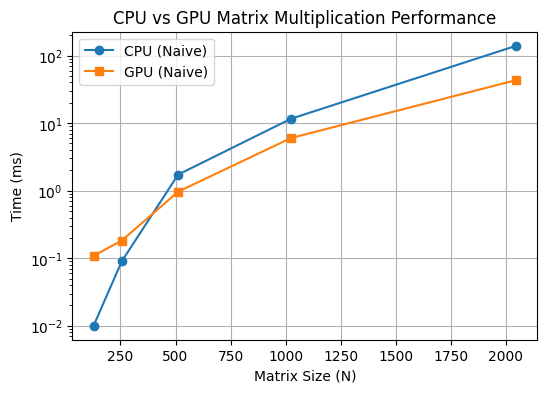

In [31]:
import subprocess
import matplotlib.pyplot as plt

# Define the matrix sizes you want to test
sizes = [128, 256, 512, 1024, 2048]
cpu_results = []
gpu_results = []

for n in sizes:
    print(f"Benchmarking N={n}...")

    # Run CPU binary: pass 'n' as a command line argument
    cpu_time = subprocess.check_output(['./matrix_mult_cpu', str(n)])
    cpu_results.append(float(cpu_time))

    # Run GPU binary: pass 'n' as a command line argument
    gpu_time = subprocess.check_output(['./matrix_mult_gpu', str(n)])
    gpu_results.append(float(gpu_time))

# Plotting the results
plt.figure(figsize=(6, 4))
plt.plot(sizes, cpu_results, label='CPU (Naive)', marker='o')
plt.plot(sizes, gpu_results, label='GPU (Naive)', marker='s')

plt.xlabel('Matrix Size (N)')
plt.ylabel('Time (ms)')
plt.title('CPU vs GPU Matrix Multiplication Performance')
plt.legend()
plt.grid(True)
# Use log scale if CPU time dwarfs GPU time significantly
plt.yscale('log')
plt.show()